# Разработка ML-системы по прогнозированию медианной стоимости жилья в Калифорнии. EDA

## Описание данных

- `MedInc`: Медианный доход домохозяйств в квартале (измеряется в десятках тысяч долларов).
- `HouseAge`: Медианный возраст дома в квартале.
- `AveRooms`: Среднее количество комнат на одно домохозяйство.
- `AveBedrms`: Среднее количество спален на одно домохозяйство.
- `Population`: Общая численность населения в квартале.
- `AveOccup`: Среднее число жильцов на одно домохозяйство (население ÷ количество домохозяйств).
- `Latitude`: Географическая широта квартала.
- `Longitude`: Географическая долгота квартала.

`MedHouseVal` - таргет, медианная стоимость дома для данного квартала. Выражается в сотнях тысяч долларов (например, значение `5`) означает `$500,000`.

In [16]:
# Импорты
import os
import sys
from pathlib import Path

import pandas as pd
import numpy as np
import sklearn

from sklearn.datasets import fetch_california_housing

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import ttest_ind
from scipy.stats import t

SEED = 42

In [3]:
# Загружаем данные
df = fetch_california_housing(as_frame=True)

In [4]:
df.frame.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [5]:
df.frame.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [6]:
display(df.frame.describe())

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [7]:
def boxplot(df: pd.DataFrame, cols: list) -> None:
    """
    Строит boxplot.

    Параметры:
        df (pd.DataFrame): Датафрейм для обработки
        cols (list): Список столбцов для обработки
    """
    n = len(cols)

    # Адаптивная сетка
    n_cols = min(3, n)  # максимум 3 столбца
    n_rows = (n + n_cols - 1) // n_cols  # округляем вверх

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(8 * n_cols, 6 * n_rows)
    )

    # Преобразуем axes в плоский список
    if n_rows == 1 and n_cols == 1:
        axes = [axes]
    else:
        axes = axes.flatten()

    # Строим boxplot для каждого признака
    for i, col in enumerate(cols):
        sns.boxplot(
            x=col,
            data=df,
            fill=False,
            showfliers=True,
            ax=axes[i]
        )
        axes[i].set_title(f'Распределение {col}', fontsize=14)
        axes[i].set_xlabel(col)
        axes[i].grid(axis='y', alpha=0.3)

    # Отключаем пустые оси
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.suptitle(
        'Визуальный анализ выбросов',
        fontsize=18,
        fontweight='bold',
        y=0.98
    )
    plt.tight_layout()
    plt.show()

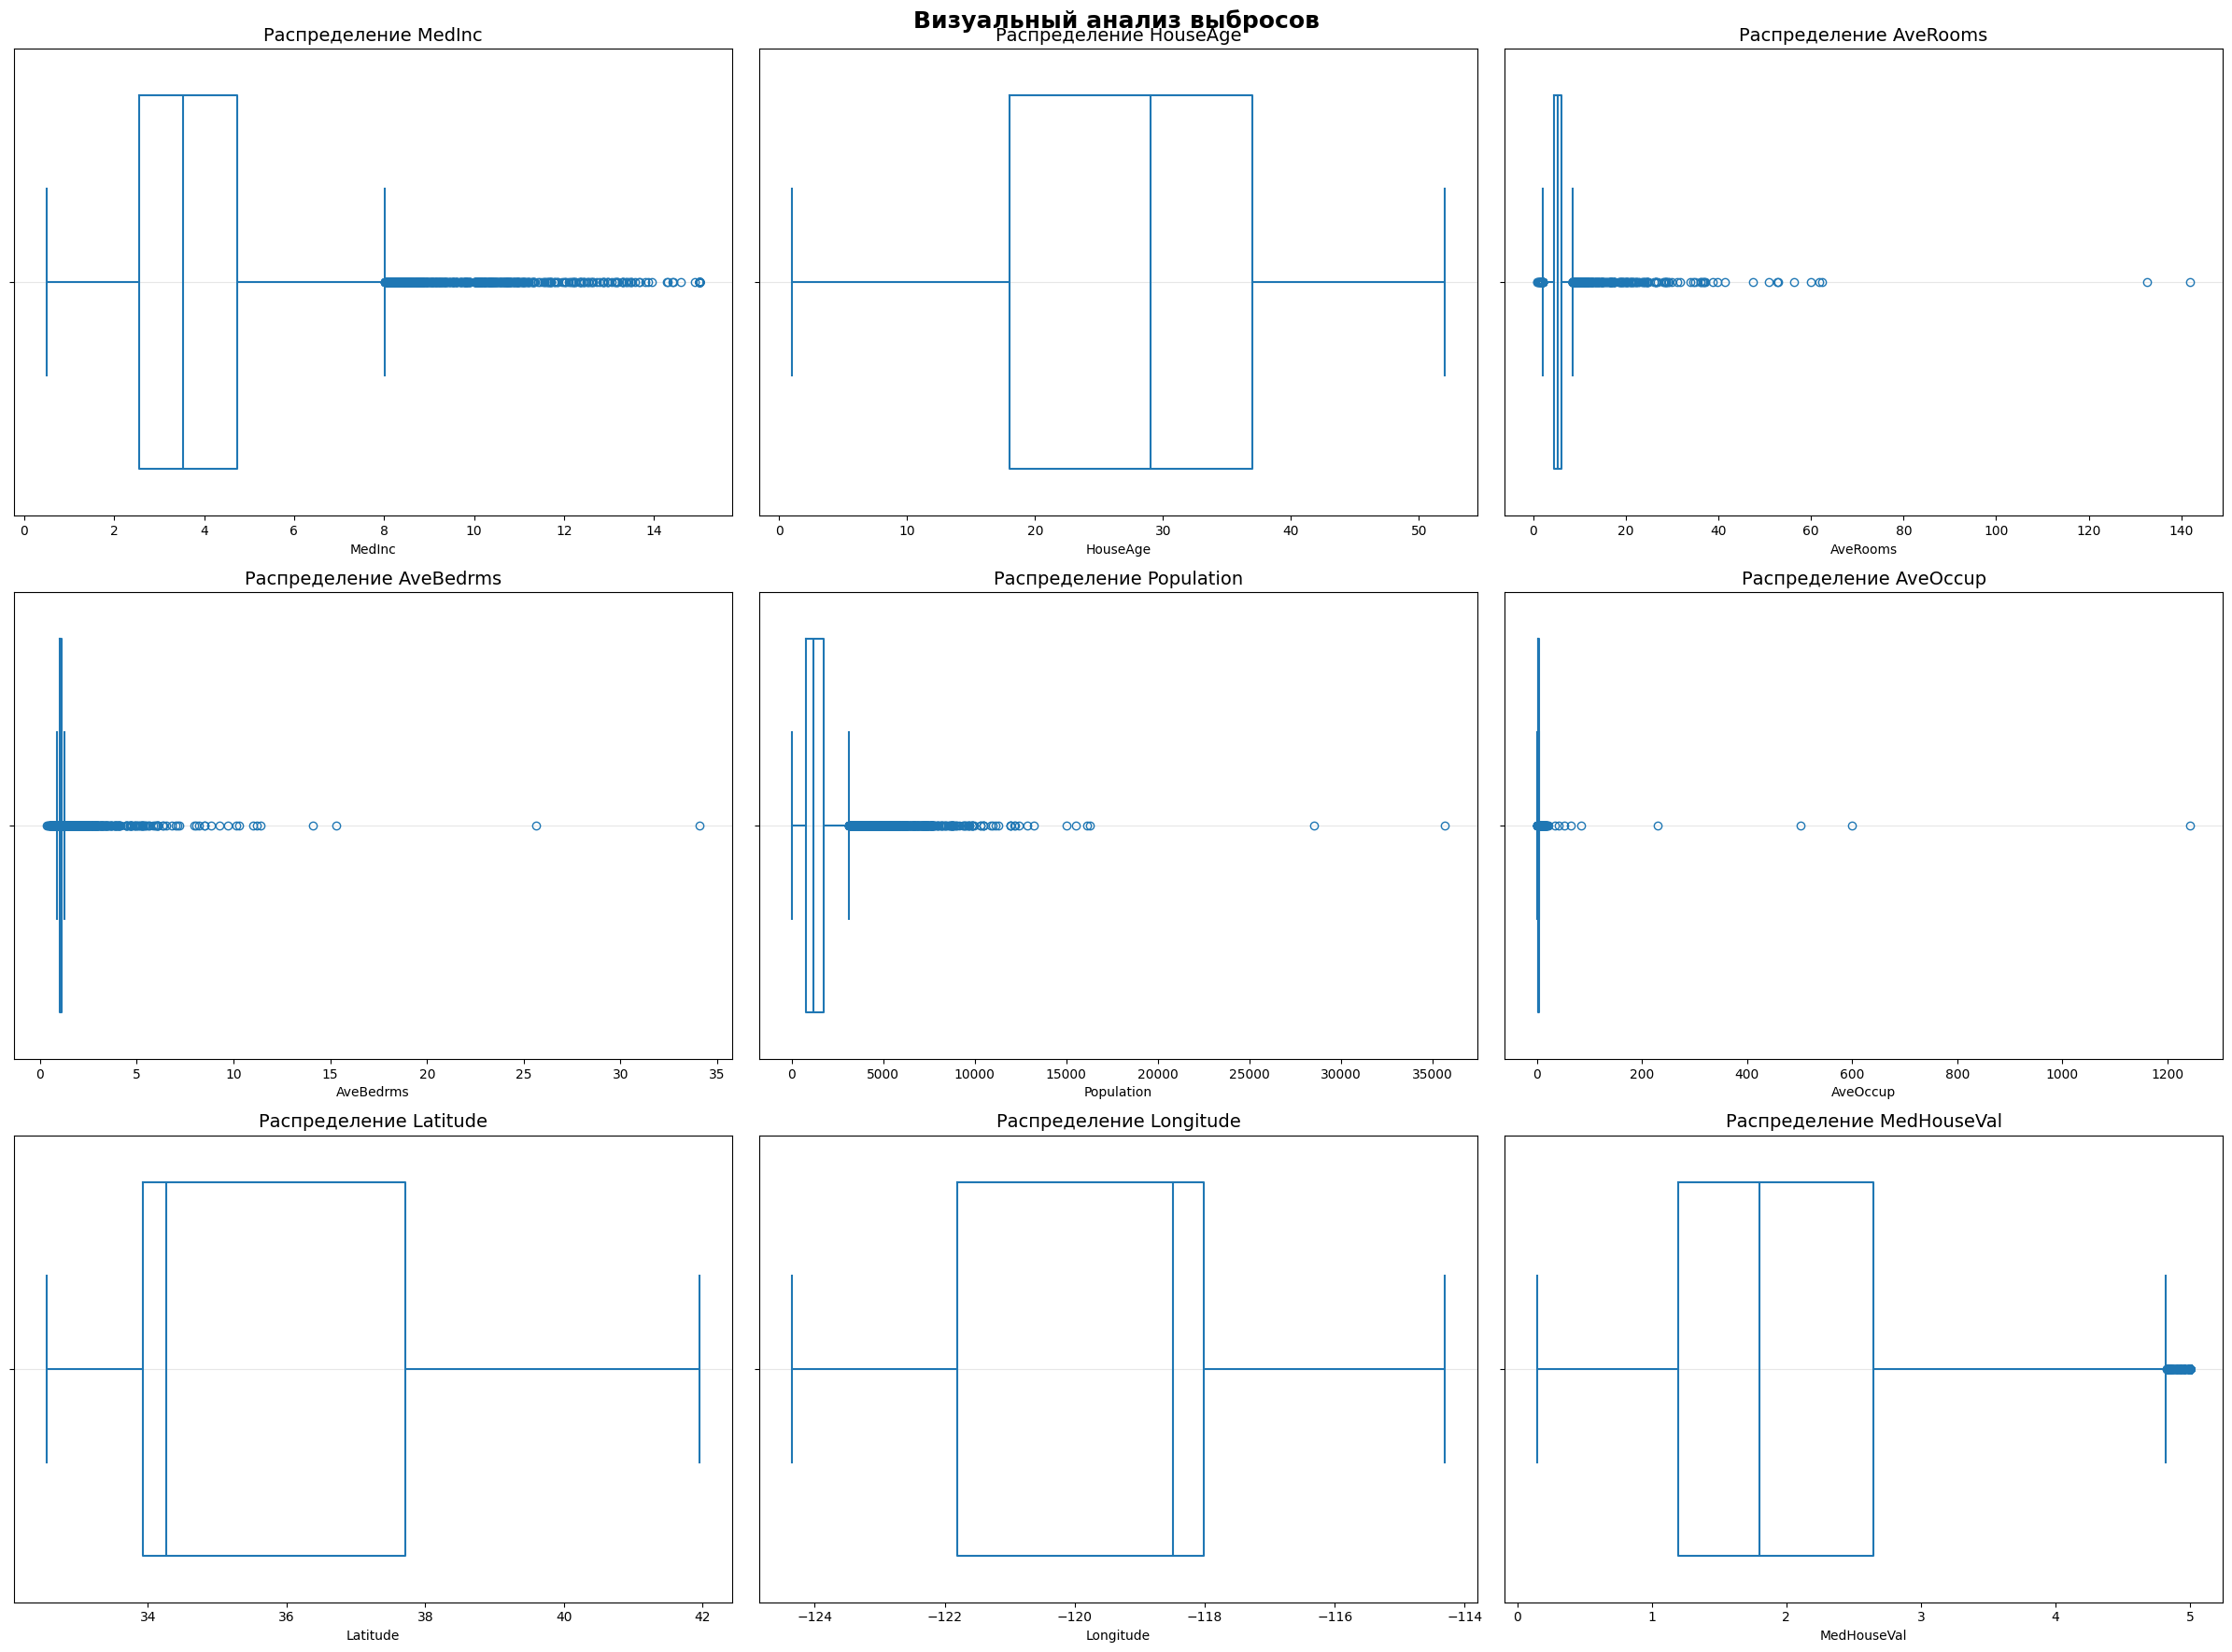

In [8]:
boxplot(df.frame, df.frame.columns)

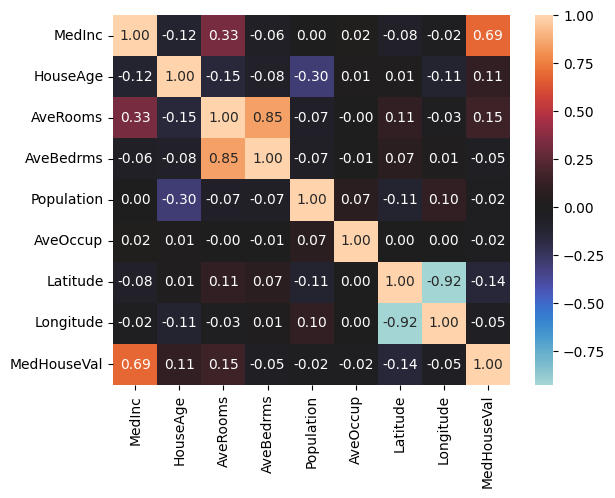

In [9]:
# Строим матрицу корреляции Пирсона
sns.heatmap(df.frame.corr(),
            annot=True,
            fmt=".2f",
            center=0)

plt.figsize=(14, 12)

## Вывод
- Пропусков нет;
- Типы данных приведены корректно;
- Аномальных или ошибочных значений не обнаружено.
- В данных присутствуют выбросы, признаки имеют разный масштаб.

Необходимо масштабирование через StandardScaler.

Взаимосвязь признаков:

- Сильно выраженная положительная корреляция между средним количеством комнат и средним количеством спален. Возможна мультиколлинеарность. Обязательная регуляризация;
-  Наибольшее влияние на медианную стоимость оказывает медианный доход домохозяйств в квартале
-  Широта и долгота имеют выраженную отрицательную корреляцию, что ожидаемо.
-  Также можно отметить слабо выраженную положительную корреляцию между средним количеством комнат и медианным доходом домохозяйств.
-  Существует слабая отрицательная корреляция между количеством проживающих в человек в квартале и медианным возрастом дома.


# Сравнение время отклика системы

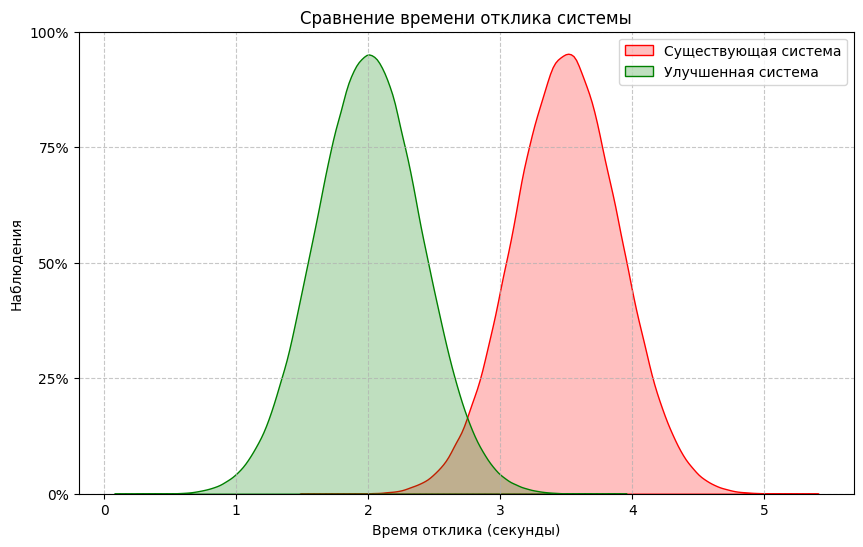

In [13]:
np.random.seed(SEED)

plt.figure(figsize=(10, 6))
existing_system_responses = np.random.normal(loc=3.5, scale=0.4, size=500000)
improved_system_responses = np.random.normal(loc=2.0, scale=0.4, size=500000)

sns.kdeplot(existing_system_responses, label='Существующая система', fill=True, color='red')
sns.kdeplot(improved_system_responses, label='Улучшенная система', fill=True, color='green')

plt.title('Сравнение времени отклика системы'); plt.xlabel('Время отклика (секунды)')

plt.ylabel('Наблюдения'); plt.legend(); plt.grid(True, linestyle='--', alpha=0.7)

ax = plt.gca()
ymin, ymax = ax.get_ylim()
num_ticks = 5
new_yticks = np.linspace(ymin, ymax, num_ticks)

new_yticklabels = [f'{int((tick / ymax) * 100)}%' if ymax != 0 else '0%' for tick in new_yticks]

ax.set_yticks(new_yticks)
ax.set_yticklabels(new_yticklabels)

plt.show()  

Сформулируем нулевую и альтернативную гипотезы:

- $H_0$: Среднее время отклика улучшенной системы равно существующей;
- $H_1$: Среднее время отклика улучшенной системы меньше, чем у существующей.

что эквивалентно:

- $H_0$: $\mu_B = \mu_A$ vs $H_1:$ $\mu_B < \mu_A$

Для проверки гипотезы будем применить односторонний t_test.
$\alpha$ возьмем стандартный равный 0.05.
Доверительный интервал $\beta$ равен 0.95 соответственно.

In [26]:
np.random.seed(SEED)

alpha = 0.05

stat, p_value = ttest_ind(improved_system_responses, existing_system_responses, alternative='less')

print(f"p_value: {p_value:.4f}")
print(f"т_статистика: {stat:.4f}")

if p_value > alpha:
    print("Нет достаточных оснований отвергнуть нулевую гипотезу: разница незначимо.")
    print("Решение: ничего не менять, продолжить мониторинг.")
else:
    print("Отвергаем нулевую гипотезу: время отлика новой системы меньше, чем у существующей.")
    print("Решение: рассмотреть внедрение новой системы.")

p_value: 0.0000
т_статистика: -1875.0793
Отвергаем нулевую гипотезу: время отлика новой системы меньше, чем у существующей.
Решение: рассмотреть внедрение новой системы.


In [19]:
# Разница средних
diff_mean = improved_system_responses.mean() - existing_system_responses.mean()

# Стандартная ошибка разницы
se = np.sqrt(
    improved_system_responses.var()/len(improved_system_responses) + existing_system_responses.var()/len(existing_system_responses)
)

# Степени свободы Уэлча
df = (improved_system_responses.var()/len(improved_system_responses) + existing_system_responses.var()/len(existing_system_responses))**2 / (
    (improved_system_responses.var()/len(improved_system_responses))**2/(len(improved_system_responses)-1) +
    (existing_system_responses.var()/len(existing_system_responses))**2/(len(existing_system_responses)-1)
)

# 95% доверительный интервал
alpha = 0.05
t_crit = t.ppf(1 - alpha/2, df)
ci_lower = diff_mean - t_crit * se
ci_upper = diff_mean + t_crit * se

print(f"Разница средних (improved - existing): {diff_mean:.4f} с")
print(f"95% ДИ: [{ci_lower:.4f}, {ci_upper:.4f}] с")

Разница средних (improved - existing): -1.5003 с
95% ДИ: [-1.5019, -1.4988] с


Полученное значение p_value < $\alpha$, следовательно время отклика новой системы меньше, чем у старой, и это различие статистически значимо. 

95% доверительный интервал для среднего времени отклика двух систем не включает ноль, что подтверждает статистическую значимость улучшения.

Принимаем альтернативную гипотезу.

Результаты зафиксированы в [ADR](docs/adr/002-latency-improvement.md)